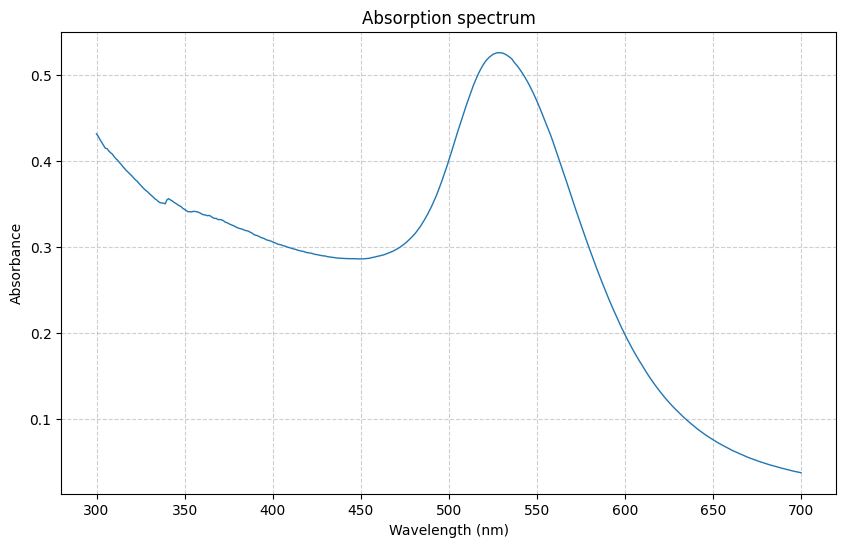

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных из файла (пропускаем первую строку с "1C.SPC")
df = pd.read_csv('1C.csv', skiprows=1)

# Первый столбец — WL (длина волны), второй — Abs (поглощение)
x = df.iloc[:, 0]  # первый столбец
y = df.iloc[:, 1]  # второй столбец

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(x, y, linewidth=1)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')
plt.title('Absorption spectrum')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Локальный максимум (пик) найден при:
Длина волны: 341.0 nm
Поглощение: 0.3564


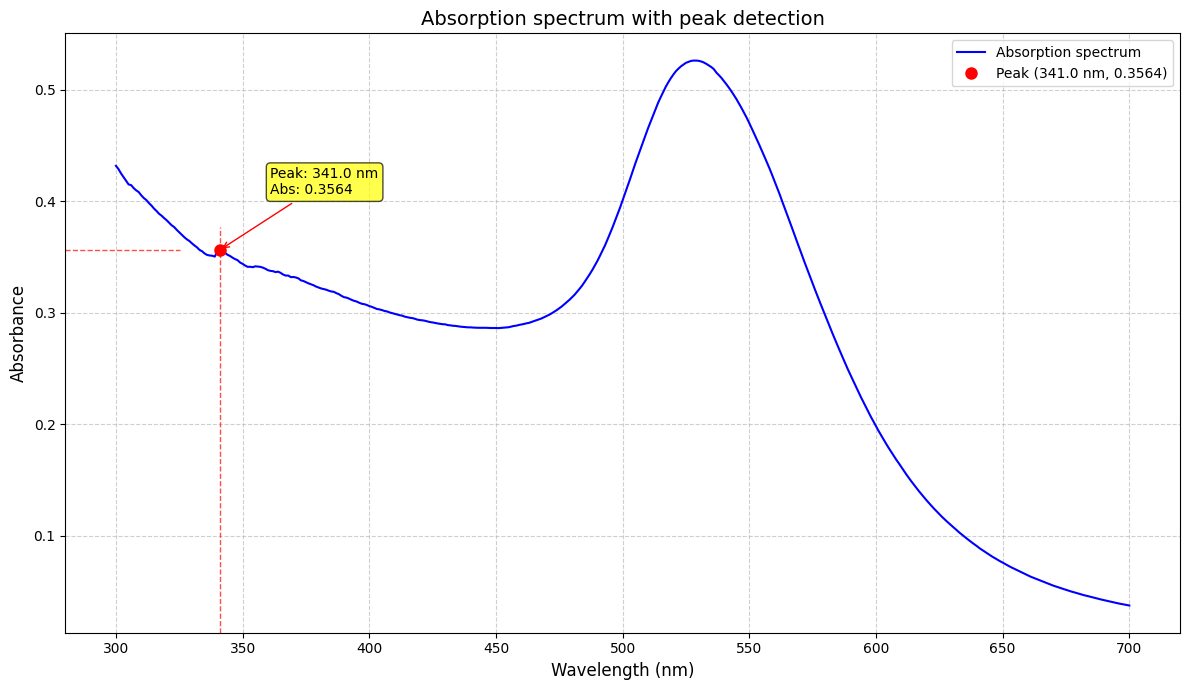

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных из файла (пропускаем первую строку с "1C.SPC")
df = pd.read_csv('1C.csv', skiprows=1)

# Первый столбец — WL (длина волны), второй — Abs (поглощение)
x = df.iloc[:, 0].values  # первый столбец
y = df.iloc[:, 1].values  # второй столбец

# Поиск локального максимума (пика)
# Ищем точку, где производная меняет знак с + на -
maxima_indices = []
for i in range(1, len(y) - 1):
    if y[i] > y[i-1] and y[i] > y[i+1]:
        maxima_indices.append(i)

# Выбираем глобальный максимум из найденных локальных
if maxima_indices:
    # Находим индекс с максимальным значением y
    peak_idx = max(maxima_indices, key=lambda i: y[i])
    peak_x = x[peak_idx]
    peak_y = y[peak_idx]
else:
    # Если локальных максимумов не найдено, берём просто максимум массива
    peak_idx = np.argmax(y)
    peak_x = x[peak_idx]
    peak_y = y[peak_idx]

# Построение графика
plt.figure(figsize=(12, 7))
plt.plot(x, y, linewidth=1.5, label='Absorption spectrum', color='blue')

# Отмечаем точку экстремума
plt.plot(peak_x, peak_y, 'ro', markersize=8, label=f'Peak ({peak_x:.1f} nm, {peak_y:.4f})')

# Рисуем вертикальную линию от точки до оси X
plt.axvline(x=peak_x, ymin=0, ymax=peak_y/max(y), 
            color='red', linestyle='--', linewidth=1, alpha=0.7)

# Дополнительно: горизонтальная линия до оси Y
plt.axhline(y=peak_y, xmin=0, xmax=(peak_x - min(x))/(max(x)-min(x)),
            color='red', linestyle='--', linewidth=1, alpha=0.7)

# Настройки графика
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Absorbance', fontsize=12)
plt.title('Absorption spectrum with peak detection', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Добавляем аннотацию с координатами пика
plt.annotate(f'Peak: {peak_x:.1f} nm\nAbs: {peak_y:.4f}',
             xy=(peak_x, peak_y),
             xytext=(peak_x + 20, peak_y + 0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=1),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Выводим информацию в консоль
print(f'Локальный максимум (пик) найден при:')
print(f'Длина волны: {peak_x:.1f} nm')
print(f'Поглощение: {peak_y:.4f}')

plt.tight_layout()
plt.show()

Поиск максимума в диапазоне 510-540 нм:
Длина волны: 529.0 nm
Поглощение: 0.5264


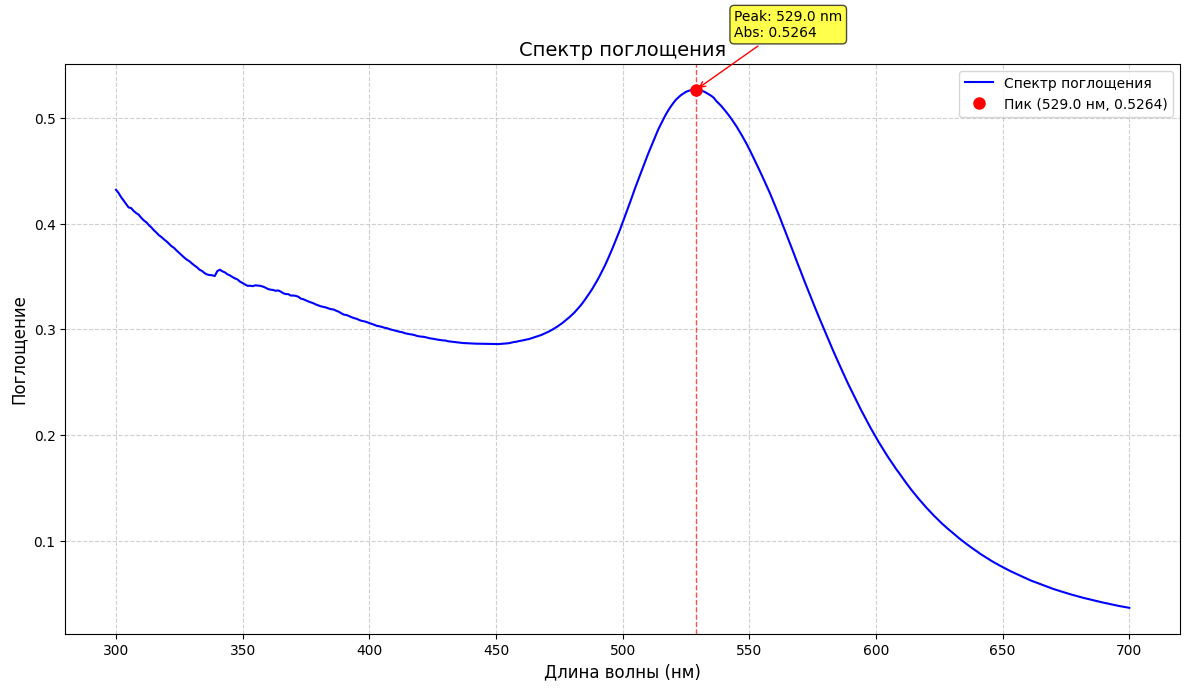

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных из файла (пропускаем первую строку с "1C.SPC")
df = pd.read_csv('1C.csv', skiprows=1)

# Первый столбец — WL (длина волны), второй — Abs (поглощение)
x = df.iloc[:, 0].values  # первый столбец
y = df.iloc[:, 1].values  # второй столбец

# Задаём диапазон поиска максимума (510-540 нм)
min_wavelength = 510
max_wavelength = 540

# Создаём маску для диапазона
mask = (x >= min_wavelength) & (x <= max_wavelength)

# Извлекаем данные только в заданном диапазоне
x_range = x[mask]
y_range = y[mask]

if len(x_range) == 0:
    print(f'Внимание: в диапазоне {min_wavelength}-{max_wavelength} нм нет данных!')
    # Если данных нет, ищем глобальный максимум
    peak_idx = np.argmax(y)
    peak_x = x[peak_idx]
    peak_y = y[peak_idx]
else:
    # Находим индекс глобального максимума в указанном диапазоне
    peak_idx_in_range = np.argmax(y_range)
    peak_x = x_range[peak_idx_in_range]
    peak_y = y_range[peak_idx_in_range]
    
    # Находим соответствующий индекс в исходном массиве (для построения линий)
    peak_idx = np.where(x == peak_x)[0][0]

# Построение графика
plt.figure(figsize=(12, 7))
plt.plot(x, y, linewidth=1.5, label='Спектр поглощения', color='blue')

# Отмечаем точку экстремума
plt.plot(peak_x, peak_y, 'ro', markersize=8, label=f'Пик ({peak_x:.1f} нм, {peak_y:.4f})')

# Рисуем вертикальную линию от точки до оси X
plt.axvline(x=peak_x, ymin=0, ymax=peak_y/max(y), 
            color='red', linestyle='--', linewidth=1, alpha=0.7)

# Дополнительно: горизонтальная линия до оси Y
#plt.axhline(y=peak_y, xmin=0, xmax=(peak_x - min(x))/(max(x)-min(x)),
 #           color='red', linestyle='--', linewidth=1, alpha=0.7)

# Закрашиваем область поиска для наглядности
#plt.axvspan(min_wavelength, max_wavelength, alpha=0.1, color='green', label=f'Search range: {min_wavelength}-{max_wavelength} nm')

# Настройки графика
plt.xlabel('Длина волны (нм)', fontsize=12)
plt.ylabel('Поглощение', fontsize=12)
plt.title(f'Спектр поглощения', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Добавляем аннотацию с координатами пика
plt.annotate(f'Peak: {peak_x:.1f} nm\nAbs: {peak_y:.4f}',
             xy=(peak_x, peak_y),
             xytext=(peak_x + 15, peak_y + 0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=1),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Выводим информацию в консоль
print(f'Поиск максимума в диапазоне {min_wavelength}-{max_wavelength} нм:')
print(f'Длина волны: {peak_x:.1f} nm')
print(f'Поглощение: {peak_y:.4f}')

plt.tight_layout()
plt.savefig('abs_peak.jpg')
plt.show()

РЕЗУЛЬТАТЫ РАСЧЁТА:
Заданное значение λ_max = 529.0 нм
Найденное значение d = 43.79 нм
Погрешность: |λ_max(d) - 529.0| = 0.0000 нм

Проверка: λ_max(43.79) = 529.00 нм


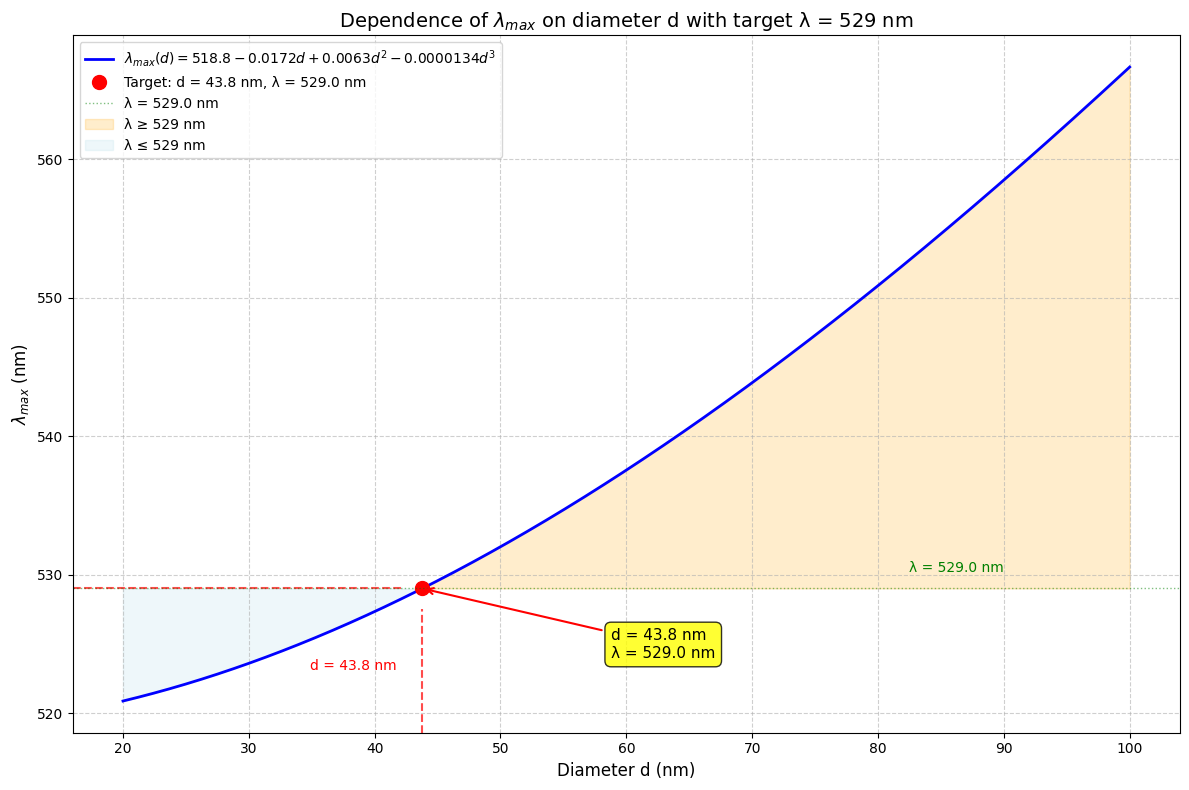

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Функция зависимости lambda_max от d
def lambda_max(d):
    return 518.8 - 0.0172 * d + 0.0063 * d**2 - 0.0000134 * d**3

# Диапазон d от 20 до 100 нм
d_range = np.linspace(20, 100, 1000)
lambda_vals = lambda_max(d_range)

# Заданное значение lambda_max
target_lambda = 529.0  # нм

# Поиск d для заданного lambda_max (решение обратной задачи)
# Ищем точку, где lambda_max(d) наиболее близка к target_lambda
idx = np.argmin(np.abs(lambda_vals - target_lambda))
d_target = d_range[idx]
lambda_at_d = lambda_vals[idx]

# Более точный поиск с помощью интерполяции (для большей точности)
from scipy.optimize import fsolve

# Определяем функцию для поиска корня: lambda_max(d) - target_lambda = 0
def equation(d):
    return lambda_max(d) - target_lambda

# Поиск корня в интервале от 20 до 100
try:
    from scipy.optimize import fsolve
    d_precise = fsolve(equation, 50)[0]
    # Проверяем, что корень в нужном диапазоне
    if 20 <= d_precise <= 100:
        d_target = d_precise
        lambda_at_d = lambda_max(d_target)
except:
    pass  # Если scipy нет, используем приближённое значение

# Построение графика
plt.figure(figsize=(12, 8))

# Основная кривая
plt.plot(d_range, lambda_vals, 'b-', linewidth=2, label=r'$\lambda_{max}(d) = 518.8 - 0.0172d + 0.0063d^2 - 0.0000134d^3$')

# Точка пересечения (529 нм)
plt.plot(d_target, lambda_at_d, 'ro', markersize=10, label=f'Target: d = {d_target:.1f} nm, λ = {lambda_at_d:.1f} nm')

# Вертикальная линия от точки до оси d
plt.axvline(x=d_target, ymin=0, ymax=(lambda_at_d - min(lambda_vals))/(max(lambda_vals)-min(lambda_vals)),
            color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Горизонтальная линия от точки до оси λ
plt.axhline(y=target_lambda, xmin=0, xmax=(d_target - 20)/(100 - 20),
            color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Дополнительно: горизонтальная линия на уровне 529 нм через весь график
plt.axhline(y=target_lambda, color='green', linestyle=':', linewidth=1, alpha=0.5, label=f'λ = {target_lambda} nm')

# Заливка области для наглядности
plt.fill_between(d_range, lambda_vals, target_lambda, where=(lambda_vals >= target_lambda), 
                 alpha=0.2, color='orange', label='λ ≥ 529 nm')
plt.fill_between(d_range, lambda_vals, target_lambda, where=(lambda_vals <= target_lambda), 
                 alpha=0.2, color='lightblue', label='λ ≤ 529 nm')

# Настройки графика
plt.xlabel('Diameter d (nm)', fontsize=12)
plt.ylabel(r'$\lambda_{max}$ (nm)', fontsize=12)
plt.title(r'Dependence of $\lambda_{max}$ on diameter d with target λ = 529 nm', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)

# Добавляем аннотацию с координатами точки
plt.annotate(f'd = {d_target:.1f} nm\nλ = {lambda_at_d:.1f} nm',
             xy=(d_target, lambda_at_d),
             xytext=(d_target + 15, lambda_at_d - 5),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=11,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8))

# Добавляем подписи осей с точками пересечения
plt.text(d_target - 2, min(lambda_vals) + 2, f'd = {d_target:.1f} nm', 
         ha='right', va='bottom', fontsize=10, color='red')
plt.text(max(d_range) - 10, target_lambda + 1, f'λ = {target_lambda} nm', 
         ha='right', va='bottom', fontsize=10, color='green')

# Выводим результат в консоль
print('='*50)
print(f'РЕЗУЛЬТАТЫ РАСЧЁТА:')
print(f'='*50)
print(f'Заданное значение λ_max = {target_lambda} нм')
print(f'Найденное значение d = {d_target:.2f} нм')
print(f'Погрешность: |λ_max(d) - {target_lambda}| = {abs(lambda_at_d - target_lambda):.4f} нм')
print(f'='*50)

# Проверка: вычисляем λ_max для найденного d
print(f'\nПроверка: λ_max({d_target:.2f}) = {lambda_max(d_target):.2f} нм')

plt.tight_layout()
plt.show()

РЕЗУЛЬТАТЫ РАСЧЁТА:
Заданное значение λ_max = 529.0 нм
Найденное значение d = 43.79 нм
Погрешность: |λ_max(d) - 529.0| = 0.0000 нм

Проверка: λ_max(43.79) = 529.00 нм


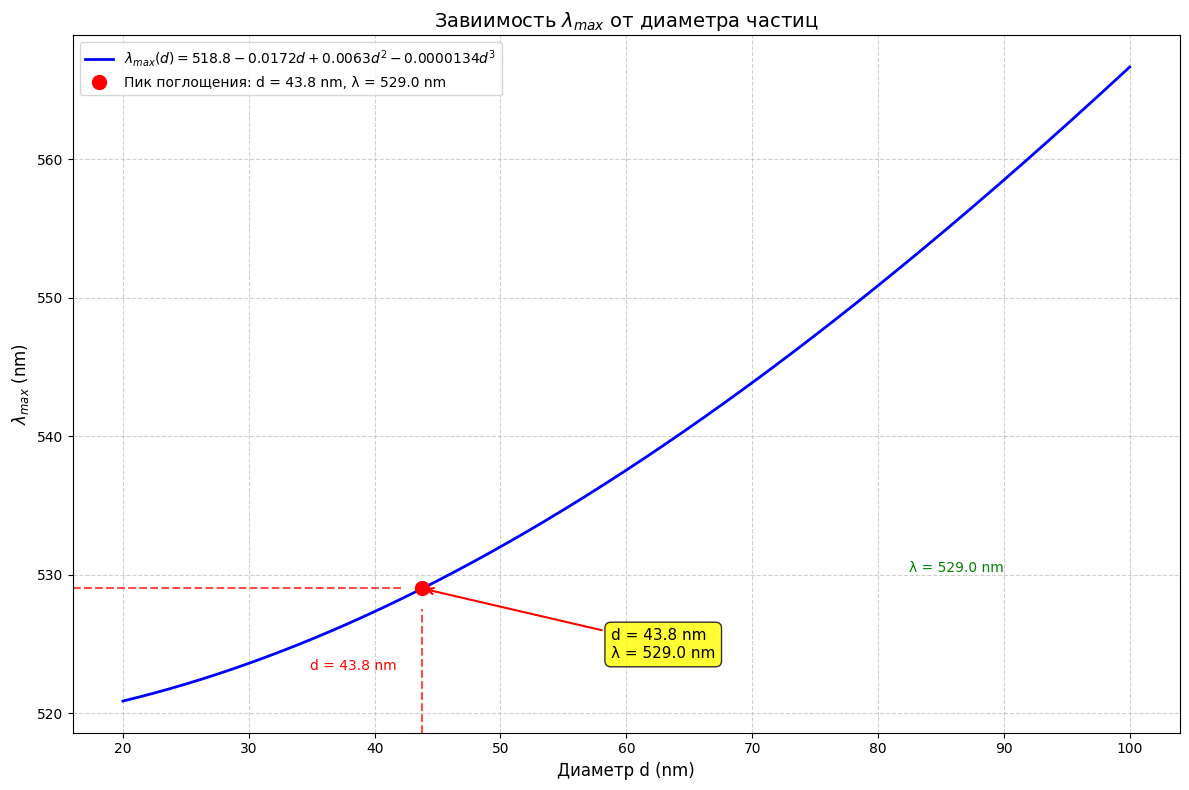

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Функция зависимости lambda_max от d
def lambda_max(d):
    return 518.8 - 0.0172 * d + 0.0063 * d**2 - 0.0000134 * d**3

# Диапазон d от 20 до 100 нм
d_range = np.linspace(20, 100, 1000)
lambda_vals = lambda_max(d_range)

# Заданное значение lambda_max
target_lambda = 529.0  # нм

# Поиск d для заданного lambda_max (решение обратной задачи)
# Ищем точку, где lambda_max(d) наиболее близка к target_lambda
idx = np.argmin(np.abs(lambda_vals - target_lambda))
d_target = d_range[idx]
lambda_at_d = lambda_vals[idx]

# Более точный поиск с помощью интерполяции (для большей точности)
def equation(d):
    return lambda_max(d) - target_lambda

# Поиск корня в интервале от 20 до 100
try:
    from scipy.optimize import fsolve
    d_precise = fsolve(equation, 50)[0]
    # Проверяем, что корень в нужном диапазоне
    if 20 <= d_precise <= 100:
        d_target = d_precise
        lambda_at_d = lambda_max(d_target)
except:
    pass  # Если scipy нет, используем приближённое значение

# Построение графика
plt.figure(figsize=(12, 8))

# Основная кривая
plt.plot(d_range, lambda_vals, 'b-', linewidth=2, label=r'$\lambda_{max}(d) = 518.8 - 0.0172d + 0.0063d^2 - 0.0000134d^3$')

# Точка пересечения (529 нм)
plt.plot(d_target, lambda_at_d, 'ro', markersize=10, label=f'Пик поглощения: d = {d_target:.1f} nm, λ = {lambda_at_d:.1f} nm')

# Вертикальная линия от точки до оси d
plt.axvline(x=d_target, ymin=0, ymax=(lambda_at_d - min(lambda_vals))/(max(lambda_vals)-min(lambda_vals)),
            color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Горизонтальная линия от точки до оси λ
plt.axhline(y=target_lambda, xmin=0, xmax=(d_target - 20)/(100 - 20),
            color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Дополнительно: горизонтальная линия на уровне 529 нм через весь график
#plt.axhline(y=target_lambda, color='green', linestyle=':', linewidth=1, alpha=0.5, label=f'λ = {target_lambda} nm')

# Настройки графика
plt.xlabel('Диаметр d (nm)', fontsize=12)
plt.ylabel(r'$\lambda_{max}$ (nm)', fontsize=12)
plt.title(r'Завиимость $\lambda_{max}$ от диаметра частиц', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)

# Добавляем аннотацию с координатами точки
plt.annotate(f'd = {d_target:.1f} nm\nλ = {lambda_at_d:.1f} nm',
             xy=(d_target, lambda_at_d),
             xytext=(d_target + 15, lambda_at_d - 5),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=11,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8))

# Добавляем подписи осей с точками пересечения
plt.text(d_target - 2, min(lambda_vals) + 2, f'd = {d_target:.1f} nm', 
         ha='right', va='bottom', fontsize=10, color='red')
plt.text(max(d_range) - 10, target_lambda + 1, f'λ = {target_lambda} nm', 
         ha='right', va='bottom', fontsize=10, color='green')

# Выводим результат в консоль
print('='*50)
print(f'РЕЗУЛЬТАТЫ РАСЧЁТА:')
print(f'='*50)
print(f'Заданное значение λ_max = {target_lambda} нм')
print(f'Найденное значение d = {d_target:.2f} нм')
print(f'Погрешность: |λ_max(d) - {target_lambda}| = {abs(lambda_at_d - target_lambda):.4f} нм')
print(f'='*50)

# Проверка: вычисляем λ_max для найденного d
print(f'\nПроверка: λ_max({d_target:.2f}) = {lambda_max(d_target):.2f} нм')

plt.tight_layout()
plt.savefig('lambda max.jpg')
plt.show()